In [2]:
import httpx
import time
import pandas as pd
import re
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import json
from pathlib import Path
import numpy as np
from tqdm.auto import tqdm
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

/Users/mnatali/Projects/sentiment_analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipping import of cpp extensions due to incompatible torch version 2.9.1 for torchao version 0.16.0             Please see https://github.com/pytorch/ao/issues/2919 for more info
W0729 09:58:26.783000 66976 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [3]:
language_classifier = pipeline(
    "text-classification",
    model = "papluca/xlm-roberta-base-language-detection"
)

def lang_result(text):
    results = language_classifier(
        text,
        truncation=True
    )
    return results[0]["label"]

model_name = "ProsusAI/finbert"

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)
model.eval()


def classify_sentiment(text, batch_size=16, max_length=512, stride=64):
    encoded = tokenizer(
        text,
        truncation=True,
        max_length=max_length,
        stride=stride,
        return_overflowing_tokens=True,
        padding=True,
        return_tensors="pt"
    )

    input_keys = ["input_ids", "attention_mask", "token_type_ids"]
    input_keys = [k for k in input_keys if k in encoded]

    all_probs = []

    with torch.inference_mode():
        n_chunks = encoded["input_ids"].shape[0]

        for start in range(0, n_chunks, batch_size):
            end = start + batch_size

            batch = {
                k: encoded[k][start:end].to(device)
                for k in input_keys
            }

            outputs = model(**batch)
            probs = F.softmax(outputs.logits, dim=-1)
            all_probs.append(probs)

    avg_probs = torch.cat(all_probs, dim=0).mean(dim=0).cpu()

    return {
        model.config.id2label[i]: float(avg_probs[i])
        for i in range(len(avg_probs))
    }

Device set to use mps:0


Using device: mps


In [4]:
print(classify_sentiment("I love the weather here! However, datacenters are a concern. The friendly neighbors hake up for it though!"))
sentiment = classify_sentiment("I love the weather here! However, datacenters are a concern. The friendly neighbors hake up for it though!")

post_sentiments = []
post_sentiment_degrees = []

post_sentiments.append(max(sentiment, key=sentiment.get))
post_sentiment_degrees.append(max(sentiment.values()))

print(post_sentiments[0], post_sentiment_degrees[0])

{'positive': 0.16127118468284607, 'negative': 0.021390993148088455, 'neutral': 0.8173378705978394}
neutral 0.8173378705978394


In [5]:
file_path = Path("/Users/mnatali/Projects/sentiment_analysis/brightdata_across_social_media_analysis/brightdata_social_exports/quora_datacenters_posts.json")

with file_path.open("r", encoding="utf-8") as f:
    quora_posts = json.load(f)

In [6]:
def remove_links(text):
    url_pattern = re.compile(r'\[https?://\S+\]|\(https?://\S+\)|\[www\.\S+\]|\(www\.\S+\)')
    cleaned_text = url_pattern.sub('', text)
    return cleaned_text

sample_string = "The board’s land use policy committee heard a presentation from the Department of Planning and Development about potential enhancements to data center use standards, including requiring a noise study and establishing a minimum distance from residential areas. The board had directed staff last May to provide research, findings and recommendations...  McKay said this process is designed to steer data centers into places that are most appropriate and make sure standards are set for environmental protections, noise mitigation and other issues that have people concerned. He said the county is learning from Loudoun and Prince William Counties, where data centers are becoming more and more prevalent...  [https://wjla.com/news/local/fairfax-county-considers-enhancing-data-center-guidelines-virginia-community-development-board-of-supervisors#](https://wjla.com/news/local/fairfax-county-considers-enhancing-data-center-guidelines-virginia-community-development-board-of-supervisors#)  A group of residents from the [Save Bren Mar From Data Center](https://sites.google.com/view/savebrenmar/home) group from the Mason District held up signs throughout Tuesday's legislative policy committee meeting, calling calling on the Fairfax county Supervisors to end by right data center development on commercial and industrial properties.  [https://patch.com/virginia/reston/data-center-zoning-policy-be-updated-fairfax-county-board](https://patch.com/virginia/reston/data-center-zoning-policy-be-updated-fairfax-county-board)Fairfax County considers enhancing data center guidelines"
result = remove_links(sample_string)
print(result)

english_post_ids = []
a = 0

for q_post in quora_posts:
    unclean_text = q_post["post_text"]
    text = remove_links(unclean_text)
    language = lang_result(text)
    pid = q_post["post_id"]
    if language == 'en':
        english_post_ids.append(pid)
    a += 1
    print("Posts scanned:", a, end="\r")

The board’s land use policy committee heard a presentation from the Department of Planning and Development about potential enhancements to data center use standards, including requiring a noise study and establishing a minimum distance from residential areas. The board had directed staff last May to provide research, findings and recommendations...  McKay said this process is designed to steer data centers into places that are most appropriate and make sure standards are set for environmental protections, noise mitigation and other issues that have people concerned. He said the county is learning from Loudoun and Prince William Counties, where data centers are becoming more and more prevalent...    A group of residents from the [Save Bren Mar From Data Center] group from the Mason District held up signs throughout Tuesday's legislative policy committee meeting, calling calling on the Fairfax county Supervisors to end by right data center development on commercial and industrial propert

In [7]:
print(len(english_post_ids))

1300


In [8]:
posts = pd.DataFrame(columns=["ids", "text", "date", "upvotes", "number of answers", "shares", "views", "sentiment", "degree", "AWS", "Amazon", "Google", "Microsoft", "Azure", "Meta", "Oracle", "Equinix", "Digital Realty", "IBM", "Facebook", "Apple", "QTS", "Vantage", "CyrusOne", "CoreSite"])

post_ids = []
post_texts = []
post_dates = []
post_upvotes = []
post_num_answers = []
post_shares = []
post_views = []
post_sentiments = []
post_sentiment_degrees = []

a = 0
links = 0

for q_post in quora_posts:
    post_id = q_post["post_id"]
    if post_id not in english_post_ids:
        continue

    a += 1

    clean_post_text = remove_links(q_post["post_text"])

    post_ids.append(q_post["post_id"])
    post_texts.append(clean_post_text)
    if q_post["post_text"] != clean_post_text:
        links += 1
    post_dates.append(q_post["post_date"])
    post_upvotes.append(q_post["upvotes"])
    post_num_answers.append(q_post["over_all_answers"])
    post_shares.append(q_post["shares"])
    post_views.append(q_post["views"])

    '''
    sentiment = classify_sentiment(clean_post_text)
    post_sentiments.append(max(sentiment, key=sentiment.get))
    post_sentiment_degrees.append(max(sentiment.values()))
    '''

    print("Posts scanned:", a, end="\r")


file_path = Path("/Users/mnatali/Projects/sentiment_analysis/testing/quora_finbert_sentiments_backup.json")

with file_path.open("r", encoding="utf-8") as f:
    sentiments = json.load(f)


post_sentiments = sentiments["sentiments"]
post_sentiment_degrees = sentiments["sentiment_degrees"]


posts["ids"] = post_ids
posts["text"] = post_texts
posts["date"] = post_dates
posts["upvotes"] = post_upvotes
posts["number of answers"] = post_num_answers
posts["shares"] = post_shares
posts["views"] = post_views
posts["sentiment"] = post_sentiments
posts["degree"] = post_sentiment_degrees

In [9]:
sentiments_backup = post_sentiments.copy()
sentiment_degrees_backup = post_sentiment_degrees.copy()

data = {
    "sentiments": post_sentiments,
    "sentiment_degrees": post_sentiment_degrees
}

with open("quora_finbert_sentiments_backup.json", "w") as f:
    json.dump(data, f)

In [10]:
posts = posts.astype({
    "ids": "string",
    "text": "string",
    "date": "string",
    "upvotes": "int64",
    "number of answers": "int64",
    "shares": "int64",
    "views": "int64",
    "sentiment": "string",
    "degree": "float64",
    "AWS": "bool",
    "Amazon": "bool",
    "Google": "bool",
    "Microsoft": "bool",
    "Azure": "bool",
    "Meta": "bool",
    "Oracle": "bool",
    "Equinix": "bool",
    "Digital Realty": "bool",
    "IBM": "bool",
    "Facebook": "bool",
    "Apple": "bool",
    "QTS": "bool",
    "Vantage": "bool",
    "CyrusOne": "bool",
    "CoreSite": "bool"
})

In [11]:
company_terms = ["AWS","Amazon","Google","Microsoft","Azure","Meta","Oracle","Equinix","Digital Realty","IBM","Facebook","Apple","QTS","Vantage","CyrusOne","CoreSite"]

for c in company_terms:
    posts[c] = posts["text"].str.contains(rf'\b{re.escape(c)}\b', case=False, na=False)

posts_with_company = posts[posts[company_terms].any(axis=1)]
posts_with_company.head()

,ids,text,date,upvotes,number of answers,shares,views,sentiment,degree,AWS,...,Oracle,Equinix,Digital Realty,IBM,Facebook,Apple,QTS,Vantage,CyrusOne,CoreSite
11,QW5zd2VyQDA6MzkyOTYxNzg=,"It Can Be Done, but it ain’t easy! Facebook In...",2017-03-16T13:23:23.398Z,4,7,0,803,neutral,0.918641,False,...,False,False,False,False,True,False,False,False,False,False
12,QW5zd2VyQDA6MzgzODkzNTk1,"32-bit processors like 80386, 486 and Pentium ...",2022-09-11T21:43:58.061Z,0,3,0,116,neutral,0.866212,False,...,False,False,False,False,False,False,False,False,False,False
17,QW5zd2VyQDA6Nzc4OTI3NA==,You're on internet. Your privacy is already co...,2014-10-31T06:28:31.712Z,6,3,0,7309,neutral,0.738342,False,...,False,False,False,False,True,False,False,False,False,False
21,QW5zd2VyQDA6MTQ3Nzc0Mzc0NjI1NjQyNQ==,Lots of potential to pass bullshit as expertis...,2024-03-13T14:47:17.023Z,0,417,6,89,positive,0.570727,False,...,True,False,False,False,False,False,False,False,False,False
23,QW5zd2VyQDA6MTQ4Mzc0Mzcy,I’m not so sure I buy your premise. Streaming ...,2019-06-18T19:42:33.034Z,2,3,0,939,neutral,0.863454,False,...,False,False,False,False,False,False,False,False,False,False


In [12]:
print(len(posts))

1300


In [13]:
print(posts.columns)

Index(['ids', 'text', 'date', 'upvotes', 'number of answers', 'shares',
       'views', 'sentiment', 'degree', 'AWS', 'Amazon', 'Google', 'Microsoft',
       'Azure', 'Meta', 'Oracle', 'Equinix', 'Digital Realty', 'IBM',
       'Facebook', 'Apple', 'QTS', 'Vantage', 'CyrusOne', 'CoreSite'],
      dtype='object')


In [14]:
## total average sentiment calculation

pos = posts.loc[posts["sentiment"] == "positive", "degree"].sum()
neg = posts.loc[posts["sentiment"] == "negative", "degree"].sum()
total = posts["degree"].sum()
print("Average sentiment for all of quora: ", (pos-neg)/total)

Average sentiment for all of quora:  -0.005847160641653224


In [15]:
pos = posts.loc[posts["sentiment"] == "positive"]
neg = posts.loc[posts["sentiment"] == "negative"]
neutral = posts.loc[posts["sentiment"] == "neutral"]

print("Percent of posts that are neutral:", len(neutral)/len(posts))
print("Percent of posts that are negative:", len(neg)/len(posts))
print("Percent of posts that are positive:", len(pos)/len(posts))

really_pos = pos.loc[posts["degree"] > 0.90]
really_neg = neg.loc[posts["degree"] > 0.90]

if len(neg) != 0:
    print("Percent of negative posts that are really negative:", len(really_neg)/len(neg))
if len(pos) != 0:
    print("Percent of positive posts that are really positive:", len(really_pos)/len(pos))

Percent of posts that are neutral: 0.93
Percent of posts that are negative: 0.04
Percent of posts that are positive: 0.03
Percent of negative posts that are really negative: 0.1346153846153846
Percent of positive posts that are really positive: 0.10256410256410256


In [16]:
def avg_sentiment_calculation(dataset):
    pos = dataset.loc[dataset["sentiment"] == "positive", "degree"].sum()
    neg = dataset.loc[dataset["sentiment"] == "negative", "degree"].sum()
    total = dataset["degree"].sum()
    if total != 0:
        return (pos-neg)/total
    else:
        return 0

posts['year'] = pd.to_datetime(posts['date']).dt.year

year_datasets = {year: posts[posts['year'] == year] for year in range(2010, 2027)}

for i in range(2010, 2027):
    print(f"Number of posts from {i}: ", len(year_datasets[i]))
    if(len(year_datasets[i]) != 0):
        print(f"Average sentiment for quora posts from {i}: ", avg_sentiment_calculation(year_datasets[i]))

Number of posts from 2010:  4
Average sentiment for quora posts from 2010:  0.0
Number of posts from 2011:  20
Average sentiment for quora posts from 2011:  0.0053621886367694735
Number of posts from 2012:  12
Average sentiment for quora posts from 2012:  0.0
Number of posts from 2013:  17
Average sentiment for quora posts from 2013:  -0.09149121730579275
Number of posts from 2014:  27
Average sentiment for quora posts from 2014:  0.0
Number of posts from 2015:  41
Average sentiment for quora posts from 2015:  -0.067910457407478
Number of posts from 2016:  77
Average sentiment for quora posts from 2016:  0.0007673742212165023
Number of posts from 2017:  129
Average sentiment for quora posts from 2017:  -0.0020035021735455103
Number of posts from 2018:  147
Average sentiment for quora posts from 2018:  -0.022074317672601526
Number of posts from 2019:  152
Average sentiment for quora posts from 2019:  -0.013173678350650997
Number of posts from 2020:  122
Average sentiment for quora posts

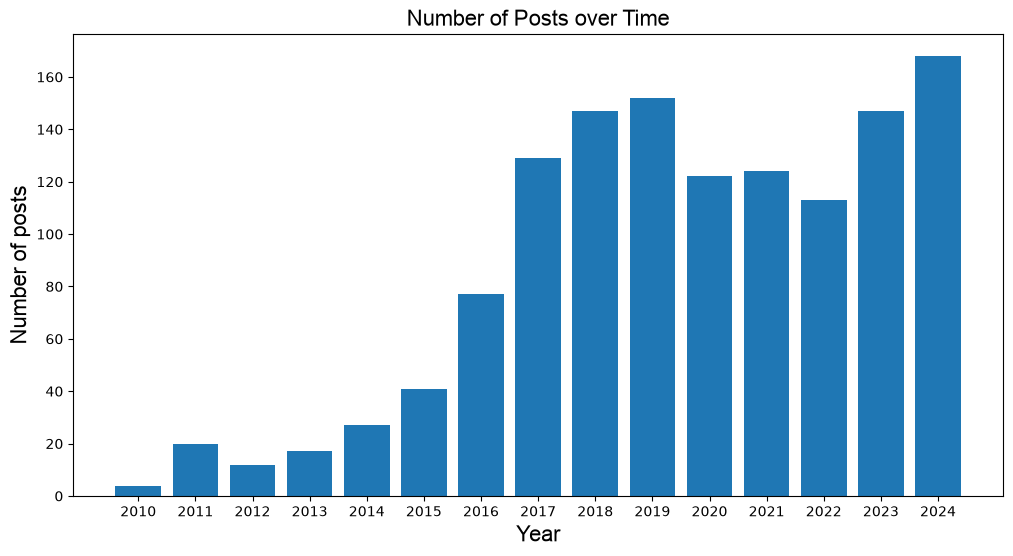

In [17]:
categories = ["2010", "2011", "2012", "2013", "2014", "2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024"]
counts = [len(year_datasets[2010]), len(year_datasets[2011]), len(year_datasets[2012]), len(year_datasets[2013]), len(year_datasets[2014]), len(year_datasets[2015]), len(year_datasets[2016]), len(year_datasets[2017]), len(year_datasets[2018]), len(year_datasets[2019]), len(year_datasets[2020]), len(year_datasets[2021]), len(year_datasets[2022]), len(year_datasets[2023]), len(year_datasets[2024])]

plt.figure(figsize=(12, 6))
plt.bar(categories, counts)

plt.title(
    "Number of Posts over Time",
    fontsize=16,
    fontname="Arial"
)

plt.xlabel(
    "Year",
    fontsize=16,
    fontname="Arial"
)

plt.ylabel(
    "Number of posts",
    fontsize=16,
    fontname="Arial"
)
plt.show()

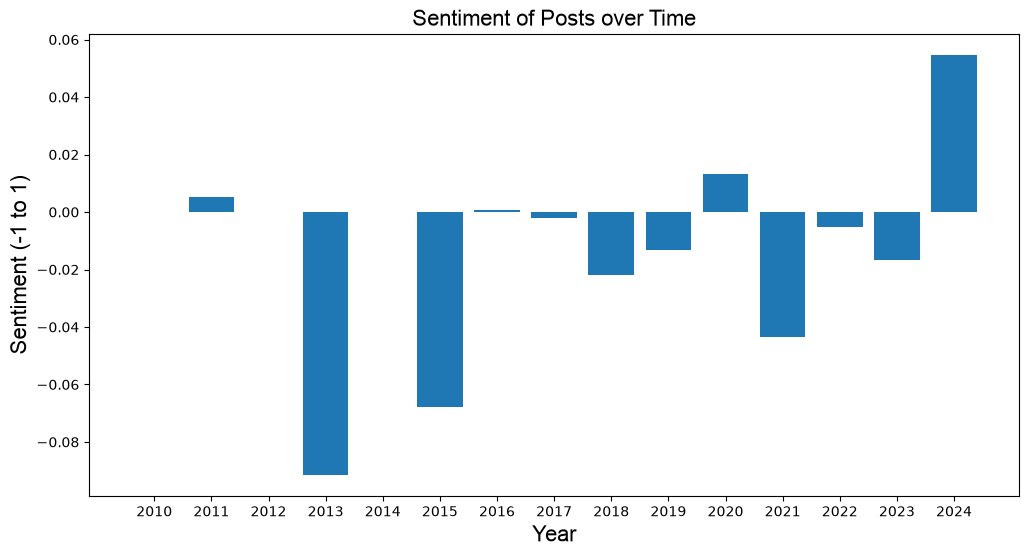

In [18]:
categories = ["2010", "2011", "2012", "2013", "2014", "2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024"]
counts = [avg_sentiment_calculation(year_datasets[2010]), avg_sentiment_calculation(year_datasets[2011]), avg_sentiment_calculation(year_datasets[2012]), avg_sentiment_calculation(year_datasets[2013]), avg_sentiment_calculation(year_datasets[2014]), avg_sentiment_calculation(year_datasets[2015]), avg_sentiment_calculation(year_datasets[2016]), avg_sentiment_calculation(year_datasets[2017]), avg_sentiment_calculation(year_datasets[2018]), avg_sentiment_calculation(year_datasets[2019]), avg_sentiment_calculation(year_datasets[2020]), avg_sentiment_calculation(year_datasets[2021]), avg_sentiment_calculation(year_datasets[2022]), avg_sentiment_calculation(year_datasets[2023]), avg_sentiment_calculation(year_datasets[2024])]

plt.figure(figsize=(12, 6))
plt.bar(categories, counts)

plt.title(
    "Sentiment of Posts over Time",
    fontsize=16,
    fontname="Arial"
)

plt.xlabel(
    "Year",
    fontsize=16,
    fontname="Arial"
)

plt.ylabel(
    "Sentiment (-1 to 1)",
    fontsize=16,
    fontname="Arial"
)
plt.show()

In [19]:
def sentiment_by_company(company1, company2=None):
    company_posts = posts[
        (posts[company1] == True) | (posts[company2] == True) if company2 else (posts[company1] == True)
    ]
    return avg_sentiment_calculation(company_posts)

print("Number of Amazon-related posts:", len(posts[posts["AWS"] == True]) + len(posts[posts["Amazon"] == True]))
print("Average sentiment of AWS-related posts:", sentiment_by_company("AWS", "Amazon"))
print("Number of Google-related posts:", len(posts[posts["Google"] == True]))
print("Average sentiment of Google-related posts:", sentiment_by_company("Google"))
print("Number of Microsoft-related posts:", len(posts[posts["Microsoft"] == True]) + len(posts[posts["Azure"] == True]))
print("Average sentiment of Microsoft-related posts:", sentiment_by_company("Microsoft", "Azure"))
print("Number of Meta-related posts:", len(posts[posts["Meta"] == True]) + len(posts[posts["Facebook"] == True]))
print("Average sentiment of Meta-related posts:", sentiment_by_company("Meta"))
print("Number of Oracle-related posts:", len(posts[posts["Oracle"] == True]))
print("Average sentiment of Oracle-related posts:", sentiment_by_company("Oracle"))
print("Number of Equinix-related posts:", len(posts[posts["Equinix"] == True]))
print("Average sentiment of Equinix-related posts:", sentiment_by_company("Equinix"))
print("Number of Digital Realty-related posts:", len(posts[posts["Digital Realty"] == True]))
print("Average sentiment of Digital Realty-related posts:", sentiment_by_company("Digital Realty"))
print("Number of IBM-related posts:", len(posts[posts["IBM"] == True]))
print("Average sentiment of IBM-related posts:", sentiment_by_company("IBM"))
print("Number of Apple-related posts:", len(posts[posts["Apple"] == True]))
print("Average sentiment of Apple-related posts:", sentiment_by_company("Apple"))
print("Number of QTS-related posts:", len(posts[posts["QTS"] == True]))
print("Average sentiment of QTS-related posts:", sentiment_by_company("QTS"))
print("Number of Vantage-related posts:", len(posts[posts["Vantage"] == True]))
print("Average sentiment of Vantage-related posts:", sentiment_by_company("Vantage"))
print("Number of CyrusOne-related posts:", len(posts[posts["CyrusOne"] == True]))
print("Average sentiment of CyrusOne-related posts:", sentiment_by_company("CyrusOne"))
print("Number of CoreSite-related posts:", len(posts[posts["CoreSite"] == True]))
print("Average sentiment of CoreSite-related posts:", sentiment_by_company("CoreSite"))

Number of Amazon-related posts: 202
Average sentiment of AWS-related posts: 0.049969103411035165
Number of Google-related posts: 304
Average sentiment of Google-related posts: 0.0006316476674429097
Number of Microsoft-related posts: 188
Average sentiment of Microsoft-related posts: 0.03373147924571402
Number of Meta-related posts: 120
Average sentiment of Meta-related posts: 0.33950929106497435
Number of Oracle-related posts: 15
Average sentiment of Oracle-related posts: 0.044420894418641874
Number of Equinix-related posts: 1
Average sentiment of Equinix-related posts: 0.0
Number of Digital Realty-related posts: 2
Average sentiment of Digital Realty-related posts: 0.0
Number of IBM-related posts: 48
Average sentiment of IBM-related posts: 0.024452263152202756
Number of Apple-related posts: 153
Average sentiment of Apple-related posts: 0.025914871537717505
Number of QTS-related posts: 0
Average sentiment of QTS-related posts: 0
Number of Vantage-related posts: 0
Average sentiment of Van

In [20]:
def analysis_of_viral_posts(min):
    viral_posts = posts.loc[posts["upvotes"] >= min]
    non_viral_posts = posts.loc[posts["upvotes"] < min]
    print("What's considered viral: posts with over", min, "upvotes")
    print("Number of viral posts:", len(viral_posts))
    print("Average sentiment of viral posts:", avg_sentiment_calculation(viral_posts))
    print("Average sentiment of non-viral posts:", avg_sentiment_calculation(non_viral_posts))
    print("Amount percent of viral posts that are polar (degree) > 0.90: ", len(viral_posts.loc[viral_posts["degree"] > 0.90])/len(viral_posts))
    print("Percent of viral posts that are negative: ", (len(viral_posts.loc[viral_posts["sentiment"] == "Negative"]))/len(viral_posts))
    print("Percent of non-viral posts that are negative: ", (len(non_viral_posts.loc[non_viral_posts["sentiment"] == "Negative"]))/(len(non_viral_posts)))

analysis_of_viral_posts(200)
print("\n")
analysis_of_viral_posts(500)
print("\n")
analysis_of_viral_posts(1000)

What's considered viral: posts with over 200 upvotes
Number of viral posts: 52
Average sentiment of viral posts: -0.02736718996212307
Average sentiment of non-viral posts: -0.0049457768392750295
Amount percent of viral posts that are polar (degree) > 0.90:  0.3076923076923077
Percent of viral posts that are negative:  0.0
Percent of non-viral posts that are negative:  0.0


What's considered viral: posts with over 500 upvotes
Number of viral posts: 33
Average sentiment of viral posts: -0.02190333632581773
Average sentiment of non-viral posts: -0.00542798017141007
Amount percent of viral posts that are polar (degree) > 0.90:  0.3333333333333333
Percent of viral posts that are negative:  0.0
Percent of non-viral posts that are negative:  0.0


What's considered viral: posts with over 1000 upvotes
Number of viral posts: 24
Average sentiment of viral posts: -0.030369303984179398
Average sentiment of non-viral posts: -0.005388761788601866
Amount percent of viral posts that are polar (degree

In [35]:
neutral_posts = posts.loc[posts["sentiment"] == "neutral"].copy()
neutral_posts.drop(columns=["AWS","Amazon","Google","Microsoft","Azure","Meta","Oracle","Equinix","Digital Realty","IBM","Facebook","Apple","QTS","Vantage","CyrusOne","CoreSite"], inplace=True)

In [36]:
model_name = "yangheng/deberta-v3-base-absa-v1.1"

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)
model.eval()


def aspect_sentiment(text, aspect, batch_size=16, max_length=512, stride=64):
    encoded = tokenizer(
        text,
        aspect,
        truncation=True,
        max_length=max_length,
        stride=stride,
        return_overflowing_tokens=True,
        padding=True,
        return_tensors="pt"
    )

    input_keys = ["input_ids", "attention_mask", "token_type_ids"]
    input_keys = [k for k in input_keys if k in encoded]

    all_probs = []

    with torch.inference_mode():
        n_chunks = encoded["input_ids"].shape[0]

        for start in range(0, n_chunks, batch_size):
            end = start + batch_size

            batch = {
                k: encoded[k][start:end].to(device)
                for k in input_keys
            }

            outputs = model(**batch)
            probs = F.softmax(outputs.logits, dim=-1)
            all_probs.append(probs)

    avg_probs = torch.cat(all_probs, dim=0).mean(dim=0).cpu()

    return {
        model.config.id2label[i]: float(avg_probs[i])
        for i in range(len(avg_probs))
    }

Using device: mps


/Users/mnatali/Projects/sentiment_analysis/.venv/lib/python3.13/site-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


In [ ]:
print(len(neutral_posts))

1209


,ids,text,date,upvotes,number of answers,shares,views,sentiment,degree,year
0,QW5zd2VyQDA6NzM1OTcyNzk=,This is a great question which is going to req...,2018-02-18T22:07:30.861Z,4,65,0,1543,neutral,0.902474,2018
1,QW5zd2VyQDA6MTQ3Nzc0Mzc1MTQ3OTk4Mg==,There are many sites that offer cloud mining s...,2024-04-04T01:33:35.222Z,0,4,0,381,neutral,0.934839,2024
2,QW5zd2VyQDA6MzQ2MzQ4MDUy,There are many things you need to consider bef...,2022-03-26T03:04:03.138Z,0,4,0,366,neutral,0.948671,2022
3,QW5zd2VyQDA6NDMyMTExMzc=,"It all depends on your credential, Japanese la...",2017-05-01T00:55:30.403Z,21,13,0,22049,neutral,0.884643,2017
5,QW5zd2VyQDA6NDYxMTM0MDY=,This wasn’t actually the question I was expect...,2017-05-31T11:56:03.654Z,3,11,0,4455,neutral,0.937708,2017


In [37]:
redo_neutral_sentiment = []
redo_neutral_sentiment_degrees = []

a = 0

for post in neutral_posts["text"]:
    sentiment = aspect_sentiment(post, "datacenters")
    redo_neutral_sentiment.append(max(sentiment, key=sentiment.get))
    redo_neutral_sentiment_degrees.append(max(sentiment.values()))
    a+=1
    print("Posts scanned:", a, end="\r")

neutral_posts["redone sentiment"] = redo_neutral_sentiment
neutral_posts["redone degree"] = redo_neutral_sentiment_degrees

neutral_posts.head()

,ids,text,date,upvotes,number of answers,shares,views,sentiment,degree,year,redone sentiment,redone degree
0,QW5zd2VyQDA6NzM1OTcyNzk=,This is a great question which is going to req...,2018-02-18T22:07:30.861Z,4,65,0,1543,neutral,0.902474,2018,Positive,0.619682
1,QW5zd2VyQDA6MTQ3Nzc0Mzc1MTQ3OTk4Mg==,There are many sites that offer cloud mining s...,2024-04-04T01:33:35.222Z,0,4,0,381,neutral,0.934839,2024,Negative,0.593209
2,QW5zd2VyQDA6MzQ2MzQ4MDUy,There are many things you need to consider bef...,2022-03-26T03:04:03.138Z,0,4,0,366,neutral,0.948671,2022,Neutral,0.937892
3,QW5zd2VyQDA6NDMyMTExMzc=,"It all depends on your credential, Japanese la...",2017-05-01T00:55:30.403Z,21,13,0,22049,neutral,0.884643,2017,Positive,0.762447
5,QW5zd2VyQDA6NDYxMTM0MDY=,This wasn’t actually the question I was expect...,2017-05-31T11:56:03.654Z,3,11,0,4455,neutral,0.937708,2017,Positive,0.450751


In [39]:
pos = neutral_posts.loc[neutral_posts["redone sentiment"] == "Positive"]
neg = neutral_posts.loc[neutral_posts["redone sentiment"] == "Negative"]
neutral = neutral_posts.loc[neutral_posts["redone sentiment"] == "Neutral"]

print("Percent of neutral posts that remained neutral:", len(neutral)/len(neutral_posts))
print("Percent of neutral posts that became negative:", len(neg)/len(neutral_posts))
print("Percent of neutral posts that became positive:", len(pos)/len(neutral_posts))

really_pos = pos.loc[neutral_posts["degree"] > 0.90]
really_neg = neg.loc[neutral_posts["degree"] > 0.90]

if len(neg) != 0:
    print("Percent of newly negative posts that are really negative:", len(really_neg)/len(neg))
if len(pos) != 0:
    print("Percent of newly positive posts that are really positive:", len(really_pos)/len(pos))

Percent of neutral posts that remained neutral: 0.3200992555831266
Percent of neutral posts that became negative: 0.228287841191067
Percent of neutral posts that became positive: 0.45161290322580644
Percent of newly negative posts that are really negative: 0.17391304347826086
Percent of newly positive posts that are really positive: 0.3974358974358974


In [42]:
posts_by_id = {post["post_id"]: post for post in quora_posts}
neutral_post_links = []
newly_positive_post_links = []
newly_negative_post_links = []

for pid in neutral_posts["ids"]:
    post = posts_by_id.get(pid)
    neutral_post_links.append(post["url"])

newly_positive_posts = neutral_posts.loc[neutral_posts["redone sentiment"] == "Positive"]
newly_negative_posts = neutral_posts.loc[neutral_posts["redone sentiment"] == "Negative"]

for pid in newly_positive_posts["ids"]:
    post = posts_by_id.get(pid)
    newly_positive_post_links.append(post["url"])

for pid in newly_negative_posts["ids"]:
    post = posts_by_id.get(pid)
    newly_negative_post_links.append(post["url"])

for pid in neutral_posts["ids"]:
    post = posts_by_id.get(pid)
    neutral_post_links.append(post["url"])

print("Links to all posts that were originally classified as neutral:", neutral_post_links)
print("Links to all posts that became positive:", newly_positive_post_links)
print("Links to all posts that became negative:", newly_negative_post_links)

Links to all posts that were originally classified as neutral: ['https://www.quora.com/Will-smartphones-ever-be-overtaken-by-something-else/answer/Robert-Bobbings', 'https://www.quora.com/What-is-the-best-legit-site-for-mining-crypto/answer/Linda-Arias-Martel', 'https://www.quora.com/How-do-we-choose-vinyl-flooring/answer/Kevin-Liu-1048', 'https://www.quora.com/Is-it-easy-to-get-a-job-in-Japan-for-foreigners/answer/Gringo-Bangayan', 'https://www.quora.com/What-is-the-difference-between-security-and-protection/answer/Shannon-Lane-7', 'https://www.quora.com/What-is-the-process-of-physical-security-in-a-network/answer/Eric-Martinson-1', 'https://www.quora.com/Can-the-wifi-owner-see-my-activities-on-Facebook-and-Messenger/answer/Jason-Scott-22', 'https://www.quora.com/Whats-the-importance-of-database-security/answer/Julie-Frey-3', 'https://www.quora.com/How-can-I-turn-100-to-1000-with-cryptocurrency-in-a-week/answer/Tuewn-Nurer', 'https://www.quora.com/Which-is-best-auto-trading-software-f